# Train and run a simplified global weather model (low hardware and data requirements)

This notebook has been tested on a 4GB GPU in a Linux environment and uses less than 3GB of training data. This notebook has also been tested in an HPC facility. There is currently a known intermittent issue on Mac hardware. 

Overview:
- Downloading training data (takes a few minutes)
- Training a neural network to predict global weather conditions (takes around 10-25 minutes per epoch depending on your hardware)
- Inferencing the network on unseen data (takes only a moment)

This demonstration allows the user to download a 2.8GB file containing around 60 years of global Earth system analysis data. Analysis means the science community's best estimate of historical weather conditions based on available observations. The data set used here was produced by the European Centre for Medium Range Weather Forecasting (ECMWF). This is a standard data set used in the field, however most research is done on a higher-resolution version of the data. That said, valuable research is also done using the lower resolution data. The spatial (latitude and longitude) resolution of this data is 64 pixels by 32 pixels, but the time series is very long. Only a few of the most interesting variables are downloaded in this notebook, to reduce how much data must be downloaded and stored.

The data is made available by the ECMWF under license, and the conditions are described here: https://www.ecmwf.int/en/forecasts/accessing-forecasts/licences-available . Please review this before making use of the data for anything. In this tutorial, the data is downloaded using instructions from the weatherbench2 data guide. Please see https://weatherbench2.readthedocs.io/en/latest/data-guide.html for more information on the data, open access, and accessing other resolutions of the data.


In [1]:
import os

# IMPORTANT! Set this to where you want to store your copy of the data!
# os.environ['ERA5LOWRESDEMO'] = os.path.expanduser("~")  # to use your home directory
# os.environ['ERA5LOWRESDEMO'] = os.path.abspath('./')    # to use the current working directory
# os.environ['ERA5LOWRESDEMO'] = os.environ['PBS_JOBFS']  # to use a job-specific temporary directory
# os.environ['ERA5LOWRESDEMO'] = os.path.abspath('/tmp')  # to use the /tmp directory

os.environ['ERA5LOWRESDEMO'] = os.path.abspath('/scratch/kd24/tjl548/')    # use /tmp by default

import hydra
import pathlib
import xarray as xr

from omegaconf import OmegaConf

import pyearthtools.data.archive
import pyearthtools.tutorial
import pyearthtools.training
import pyearthtools.pipeline

import fourcastnext

# import torch; torch.set_default_device(<YOUR_DEVICE_HERE>)  # Uncomment and set this if you need to configure a non-default device.

In [2]:
workdir = os.environ['ERA5LOWRESDEMO']
print(f'This tutorial will download a copy of the input data to {workdir}. It will also create model checkpoint files and other data here.')

if pyearthtools.data.archive.ROOT_DIRECTORIES['era5lowresdemo'] != workdir:
    print("There is some misconfiguration of your working directory, please review the commented out cells at the start of the notebook")

This tutorial will download a copy of the input data to /scratch/kd24/tjl548. It will also create model checkpoint files and other data here.


In [3]:
file_location = os.environ['ERA5LOWRESDEMO'] + '/era5_lowres.nc'

if not os.path.exists(file_location):
    print("Training data not found, downloading around 2.8GB of data")
    era5_lowres = xr.open_zarr('gs://weatherbench2/datasets/era5/1959-2022-6h-64x32_equiangular_conservative.zarr')
    subset = era5_lowres[['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure']]
    
    # IMPORTANT! Put this somewhere sensible, then set the environment variable as indicated at the start of the tutorial
    subset.to_netcdf(file_location)
    print("Wrote file to {file_location}")
    assert os.path.exists(file_location)
else:
    print("File already downloaded, skipping ...")

File already downloaded, skipping ...


In [4]:
era5_loaded = xr.open_dataset(file_location)
# era5_loaded  # Uncomment this if you want to test the file directly

In [5]:
accessor = pyearthtools.data.archive.era5_demo_subset(['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure'])

accessor['2010-01-01']

<xarray.Dataset> Size: 132kB
Dimensions:                  (time: 4, longitude: 64, latitude: 32)
Coordinates:
  * latitude                 (latitude) float64 256B -87.19 -81.56 ... 87.19
  * longitude                (longitude) float64 512B 0.0 5.625 ... 348.8 354.4
  * time                     (time) datetime64[ns] 32B 2010-01-01 ... 2010-01...
Data variables:
    10m_u_component_of_wind  (time, longitude, latitude) float32 33kB dask.array<chunksize=(4, 36, 18), meta=np.ndarray>
    10m_v_component_of_wind  (time, longitude, latitude) float32 33kB dask.array<chunksize=(4, 36, 18), meta=np.ndarray>
    2m_temperature           (time, longitude, latitude) float32 33kB dask.array<chunksize=(4, 36, 18), meta=np.ndarray>
    mean_sea_level_pressure  (time, longitude, latitude) float32 33kB dask.array<chunksize=(4, 36, 18), meta=np.ndarray>

In [6]:
config_dir = str((pathlib.Path(fourcastnext.__file__).parent / '../../Training/limited_variables_early_stopping').resolve())
                 

In [7]:
initialised = hydra.initialize_config_dir(version_base=None, config_dir = config_dir)
cfg = hydra.compose(config_name="lowres.yaml")

In [8]:
splits = {
    "train_split": pyearthtools.pipeline.iterators.DateRange(*cfg.data.splits.train),
    "valid_split": pyearthtools.pipeline.iterators.DateRange(*cfg.data.splits.valid),
}

In [9]:
pipeline_path = str((pathlib.Path(fourcastnext.__file__).parent / '../../Training/pipelines/low_res_demo_subset.pipe').resolve())

In [10]:
datamodule = pyearthtools.training.data.lightning.PipelineLightningDataModule(
    pipeline_path,
    **splits,
    **cfg.data.module
)

In [11]:
model = hydra.utils.instantiate(cfg.model)

In [12]:
checkpoint_path = os.environ['ERA5LOWRESDEMO']

In [13]:
trainer = pyearthtools.training.lightning.Train(
    model,
    datamodule,
    path=checkpoint_path,
    trainer_kwargs={'num_sanity_val_steps': 0},
    **OmegaConf.to_object(cfg.trainer)
)

In [14]:
# IMPORTANT! Uncomment this cell to fit the model. It takes a long time and produced some debugging output, so it has been commented out for display purposes.

# trainer.fit()

In [41]:
# IMPORTANT! Your checkpoints will be in a unique location based on your training!
# full_checkpoint_path = checkpoint_path + '/ML/FourCastNeXt/Training/Checkpoints/' + 'model-epoch=10-step=72000.ckpt'
full_checkpoint_path = checkpoint_path + '/ML/FourCastNeXt/Training/2025-05-03/12-58-35/Checkpoints/Train/' + 'model-epoch=10-step=72000.ckpt'
os.path.exists(full_checkpoint_path)
# os.listdir(full_checkpoint_path)

True

In [42]:
pmodel = fourcastnext.registered_model.FourCastNextRM(
    pipeline='low_res',
    output='.',
    ckpt_path = full_checkpoint_path,
    lead_time=240  # What lead time to predict out to (anywhere from 24 to 240 hours is reasonable)
)

In [44]:
pipeline_path

'/g/data/kd24/tjl/src/PyEarthTools/packages/bundled_models/fourcastnext/Training/pipelines/low_res_demo_subset.pipe'

In [43]:
# IMPORTANT! This cell must be run to produce prediction data. It produces a lot of debugging information, so it has been commented out for display purposes.
prediction = pmodel.run('2011-01-01T00')

FileNotFoundError: Cannot load 'low_res', is it a valid Pipeline?

In [18]:
data_pipeline = pyearthtools.pipeline.Pipeline(
    pyearthtools.data.archive.era5_demo_subset(['msl', '10u', '10v', '2t']),
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="-180-180"),
    fourcastnext.CropToRectangleSmall(),
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True,
        samples = ((-6, 1), (6, 2, 6))
    ),
)

In [19]:
# Plot prediction
LEAD_INTERVAL = 4 # (each interval is an additional 6 hours)
(prediction['2m_temperature'][LEAD_INTERVAL] - 273.15).plot(x='longitude', y='latitude')

NameError: name 'prediction' is not defined

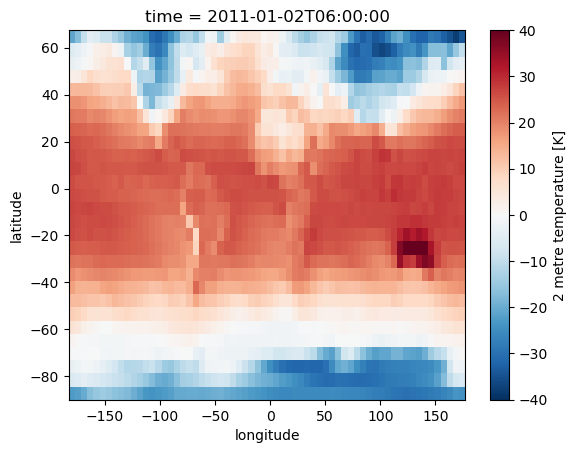

In [22]:
# Plot observation
(data_pipeline['2011-01-02T12'][0]['2m_temperature']- 273.15).plot(x='longitude', y='latitude')

# Things to try next

1. This model uses a simple crop to fit the kernel size expected by FourCastNeXt. It would be better to regrid it to the right size.
2. The model needs to train for quite a while to converge. A common problem in machine learning is not knowing quite how long to train a network. Try training it on more data, or for more epochs, and chart out how that affects the training effectiveness as measured by the loss function.
3. This notebook doesn't include any comparisons to benchmarks such as a persistence model or an alternative model. Charting skill score comparisons would be very useful.
4. A scorecard of results can also be informative, to see accuracy from multiple perspectives.
5. Charting the skill of the model with respect to lead time would also be a useful exercise.